
# 🧠 Seaborn Grandmaster EDA Codex

This notebook is designed for:

- Kaggle Competitions
- CampusX DSMP
- Industry EDA
- Interview Revision
- Fast Recall

Goal:

When you see a dataset, instantly know:

1. Which question to ask
2. Which plot to use
3. What insight to extract
4. What action to take

---

# Master Decision Tree

```text
Dataset
│
├── One Variable?
│   ├── histplot
│   ├── kdeplot
│   ├── ecdfplot
│
├── Two Numeric?
│   ├── scatterplot
│   ├── regplot
│   └── jointplot
│
├── Category vs Numeric?
│   ├── boxplot
│   ├── violinplot
│   ├── boxenplot
│   ├── stripplot
│   └── swarmplot
│
├── Time?
│   └── lineplot
│
├── Correlation?
│   ├── heatmap
│   └── clustermap
│
└── Many Features?
    ├── pairplot
    ├── PairGrid
    └── FacetGrid
```


In [28]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid')

tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')
penguins = sns.load_dataset('penguins')
titanic = sns.load_dataset('titanic')
flights = sns.load_dataset('flights')



# Histplot

### Why?
Distribution & Skewness


### Example


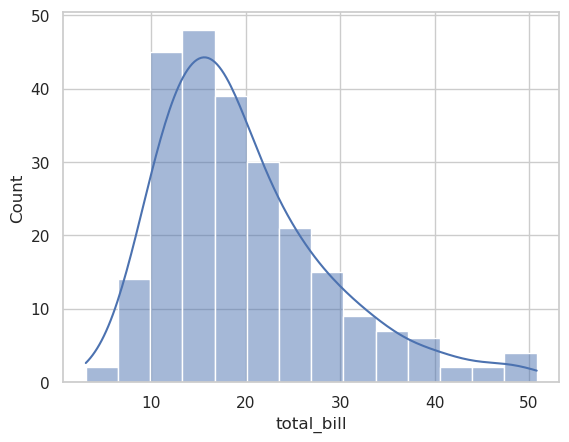

In [29]:
sns.histplot(tips['total_bill'], kde=True)
plt.show()


# KDEPlot

### Why?
Smooth Distribution


### Example


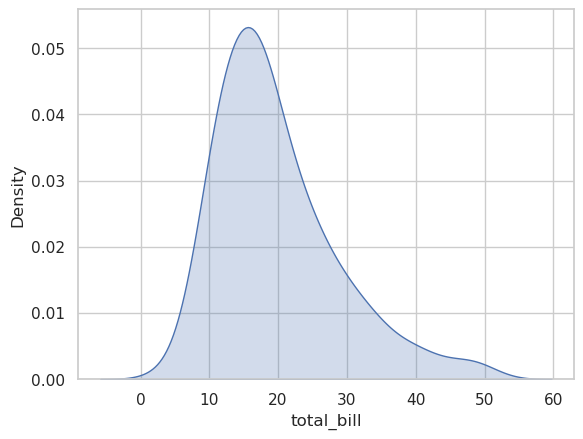

In [30]:
sns.kdeplot(tips['total_bill'], fill=True)
plt.show()


# ECDFPlot

### Why?
Percent below X



### Example


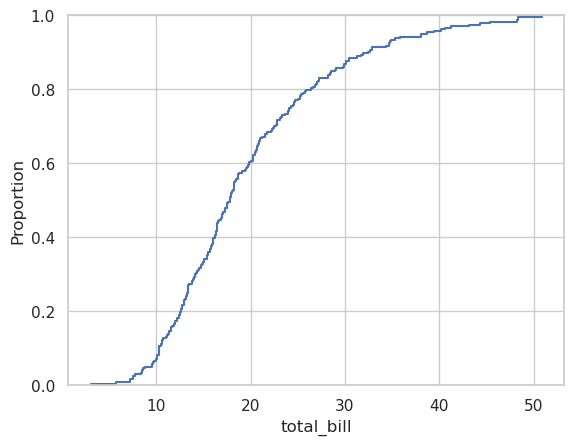

In [31]:
sns.ecdfplot(tips['total_bill'])
plt.show()


# CountPlot

### Why?
Class Imbalance


### Example


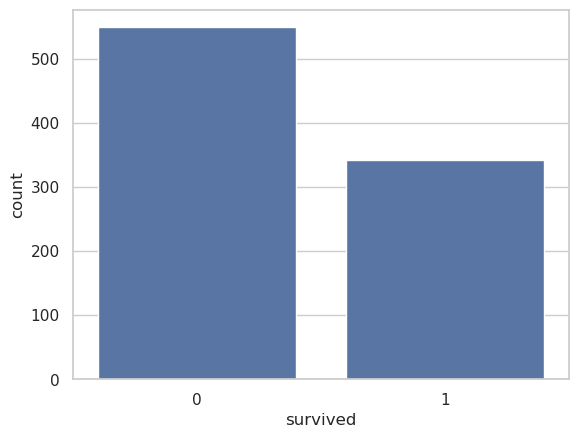

In [32]:
sns.countplot(data=titanic,x='survived')
plt.show()


# ScatterPlot

### Why?
Relationship

### Example


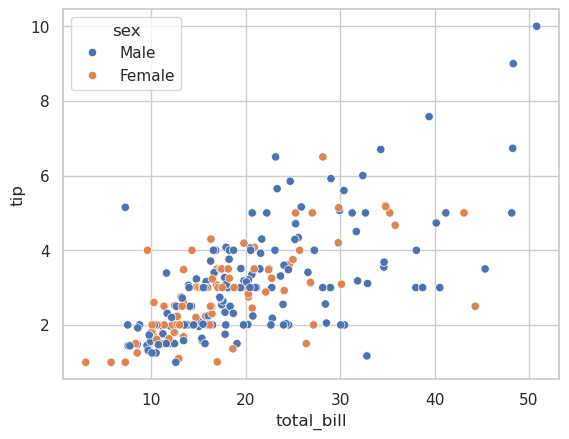

In [33]:
sns.scatterplot(data=tips,x='total_bill',y='tip',hue='sex')
plt.show()


# RegPlot

### Why?
Trend



### Example


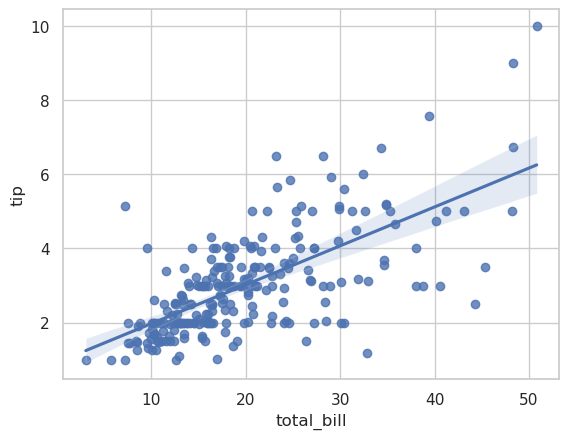

In [34]:
sns.regplot(data=tips,x='total_bill',y='tip')
plt.show()


# LinePlot

### Why?
Time Series


### Example


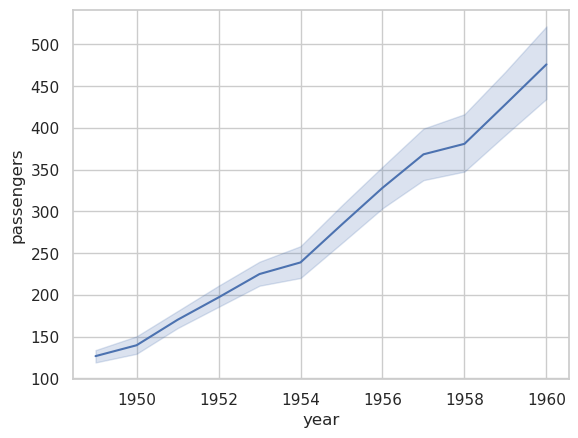

In [35]:
sns.lineplot(data=flights,x='year',y='passengers')
plt.show()


# BoxPlot

### Why?
Outliers


### Example


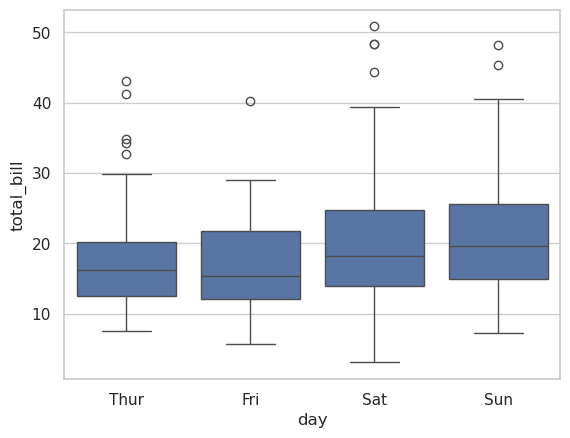

In [36]:
sns.boxplot(data=tips,x='day',y='total_bill')
plt.show()


# ViolinPlot

### Why?
Shape + Outliers

### Example


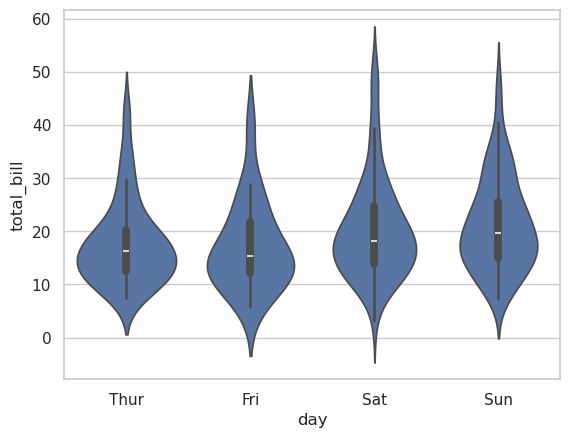

In [37]:
sns.violinplot(data=tips,x='day',y='total_bill')
plt.show()


# BoxenPlot

### Why?
Large Dataset Outliers


### Example


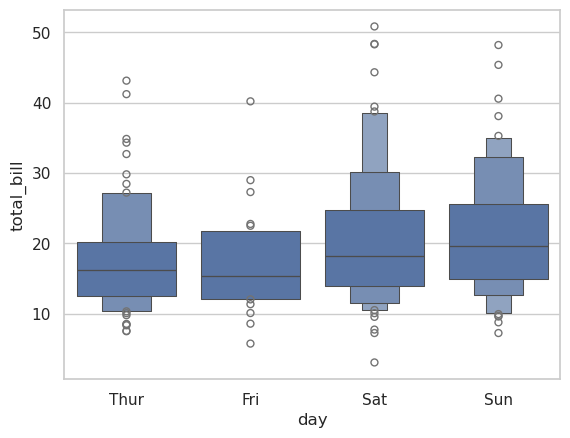

In [38]:
sns.boxenplot(data=tips,x='day',y='total_bill')
plt.show()


# StripPlot

### Why?
See Every Point



### Example


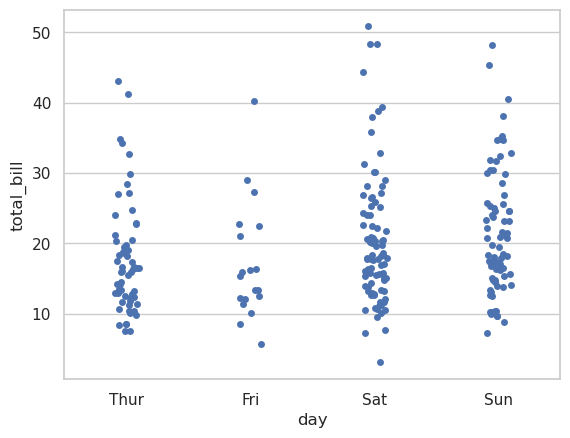

In [39]:
sns.stripplot(data=tips,x='day',y='total_bill')
plt.show()


# SwarmPlot

### Why?
No Overlap

### Example


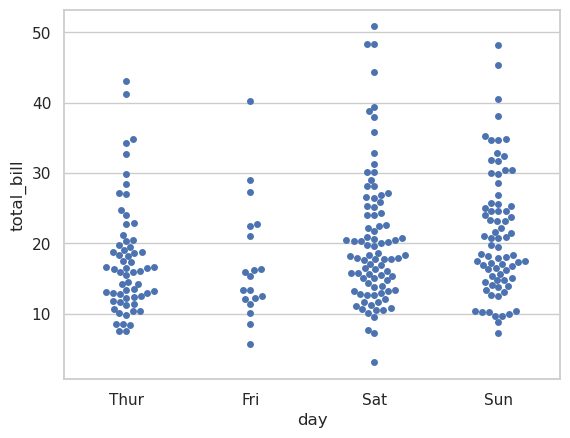

In [40]:
sns.swarmplot(data=tips,x='day',y='total_bill')
plt.show()


# BarPlot

### Why?
Mean Comparison



### Example


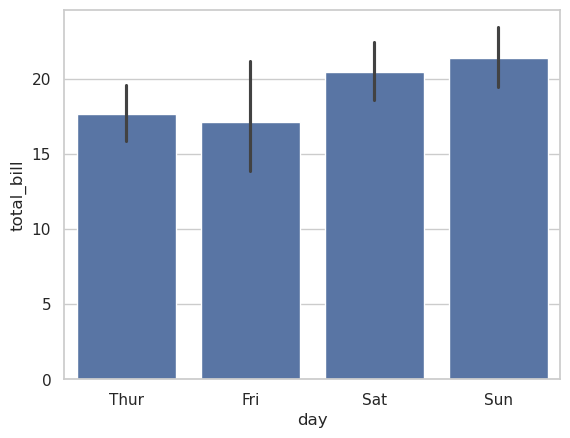

In [41]:
sns.barplot(data=tips,x='day',y='total_bill')
plt.show()


# PointPlot

### Why?
Clean Mean Comparison

### Example


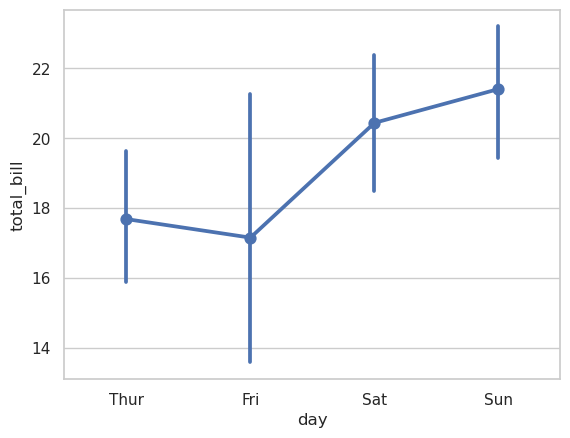

In [42]:
sns.pointplot(data=tips,x='day',y='total_bill')
plt.show()


# PairPlot

### Why?
Everything vs Everything


### Example


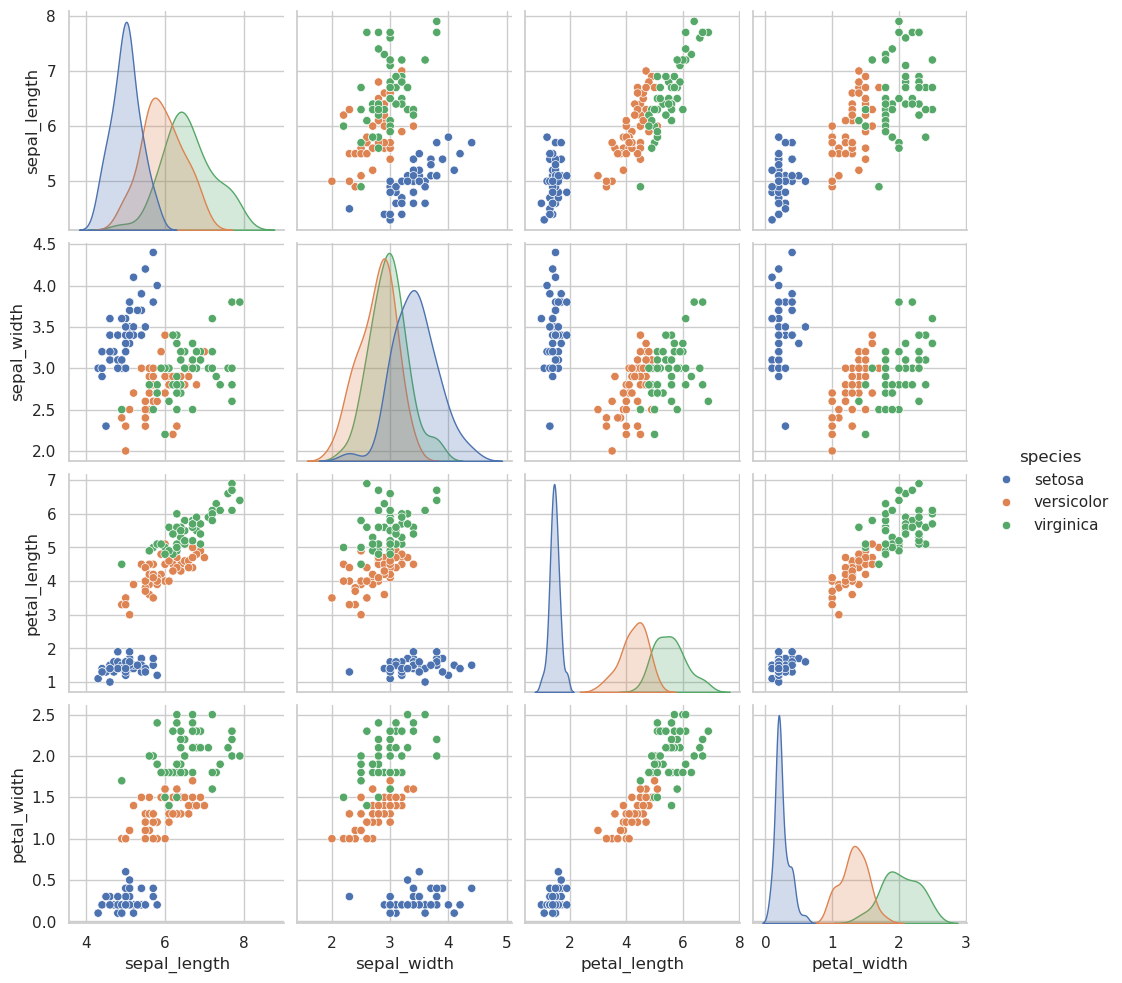

In [43]:
sns.pairplot(iris,hue='species')
plt.show()


# JointPlot

### Why?
Relationship + Distribution


### Example


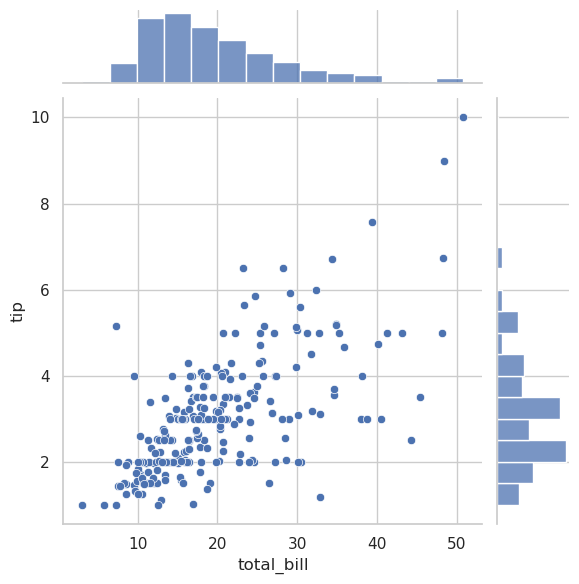

In [44]:
sns.jointplot(data=tips,x='total_bill',y='tip')
plt.show()


# Heatmaps

Memory Trick:

HEAT = CORRELATION TEMPERATURE

Positive = Hot

Negative = Cold

Use for feature selection.


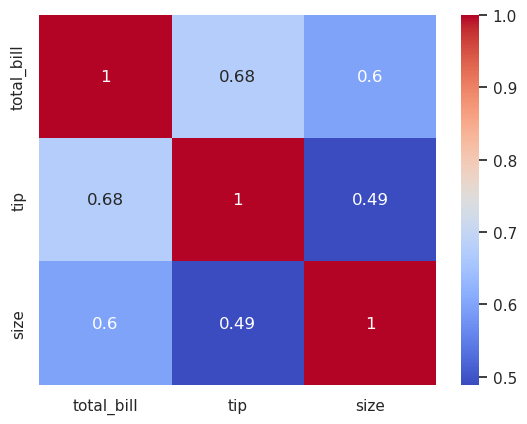

In [45]:

corr=tips.select_dtypes(include='number').corr()

sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()



# Advanced Heatmap Trick

Kaggle Standard:

Hide duplicate triangle.


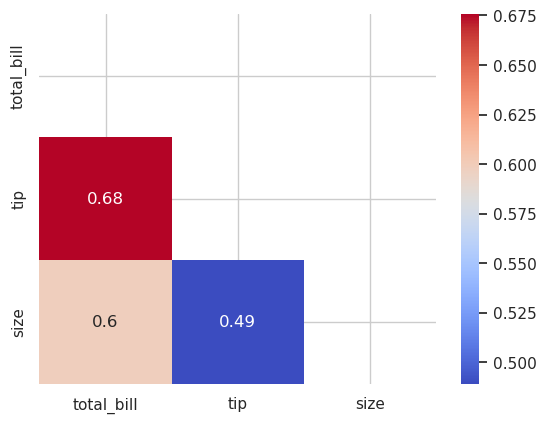

In [46]:

corr=tips.select_dtypes(include='number').corr()

mask=np.triu(np.ones_like(corr,dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm'
)
plt.show()



# ClusterMap

Memory:

Heatmap with Intelligence

Groups similar features automatically.


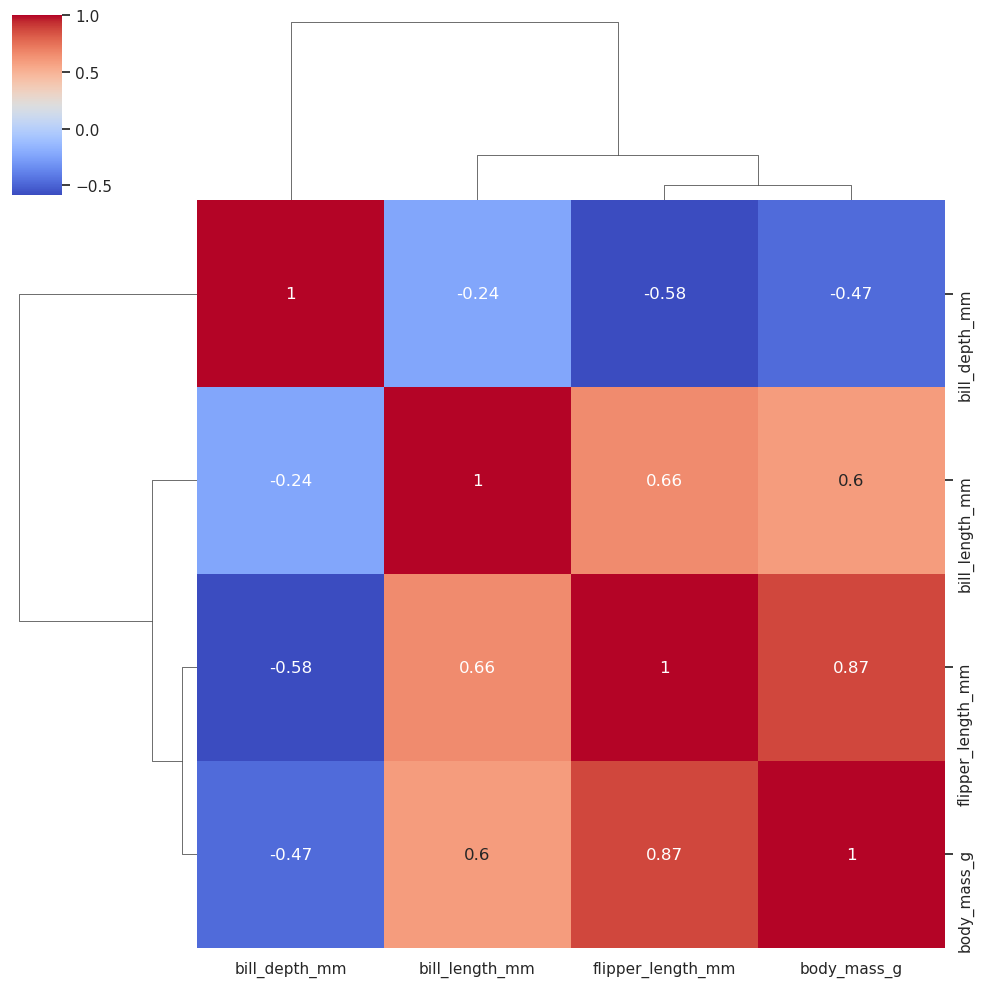

In [47]:

corr=penguins.select_dtypes(include='number').corr()

sns.clustermap(corr,annot=True,cmap='coolwarm')
plt.show()



# FacetGrid

Question:

What happens separately inside groups?


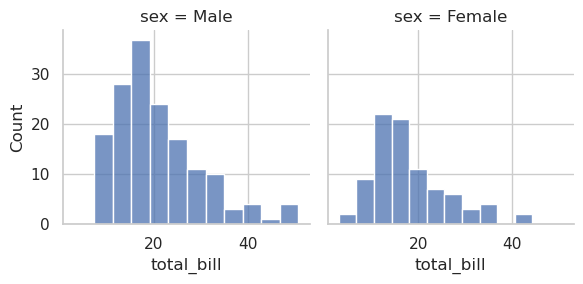

In [48]:

g=sns.FacetGrid(tips,col='sex')
g.map(sns.histplot,'total_bill')
plt.show()



# PairGrid

PairPlot on steroids.

gives manual control for which plots to be performed in upper  (above diag), lower, diag. 


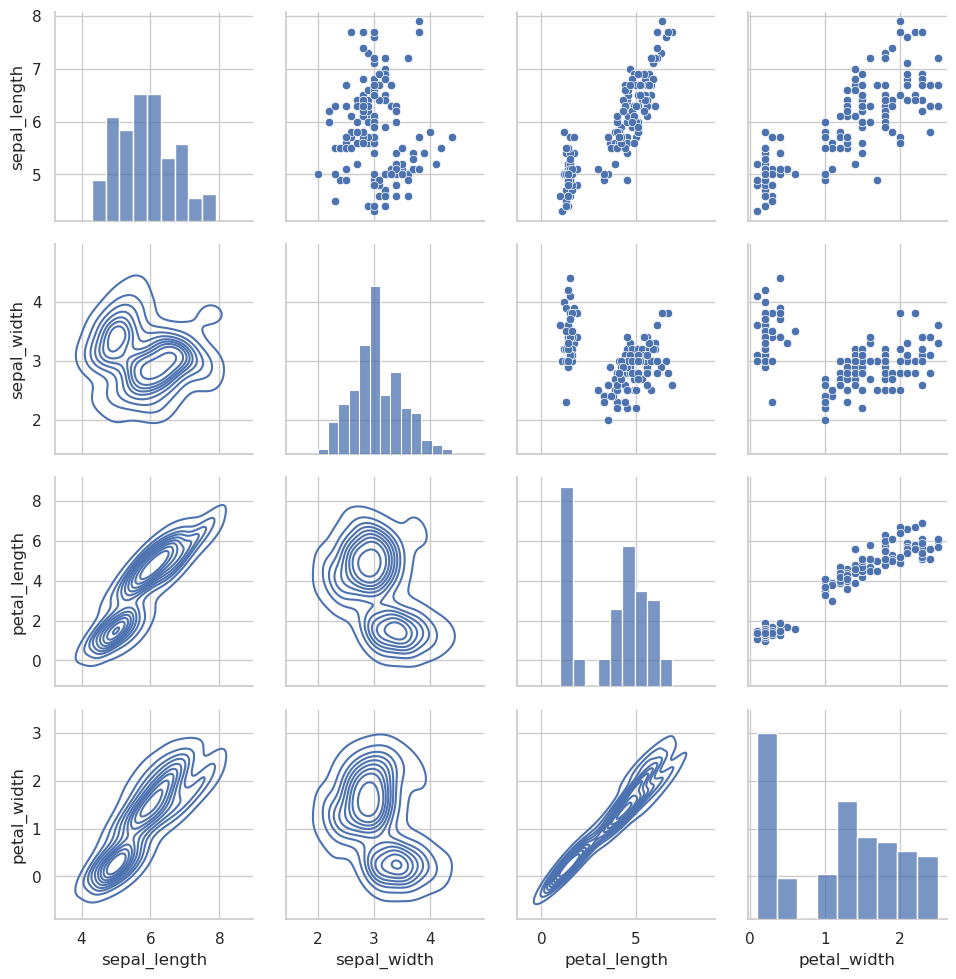

In [49]:

g=sns.PairGrid(iris)

g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.histplot)

plt.show()



# LmPlot

Regression + Grouping

Kaggle favorite.


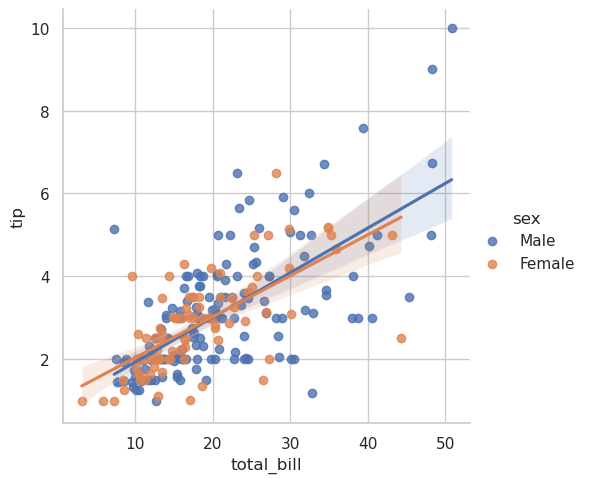

In [50]:

sns.lmplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='sex'
)
plt.show()



# Titanic Mini EDA

Real Kaggle Thinking

Questions:

1. Target imbalance?
2. Missing values?
3. Survival by Sex?
4. Survival by Class?
5. Important correlations?


In [51]:

titanic.isnull().sum().sort_values(ascending=False).head(10)


deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
dtype: int64

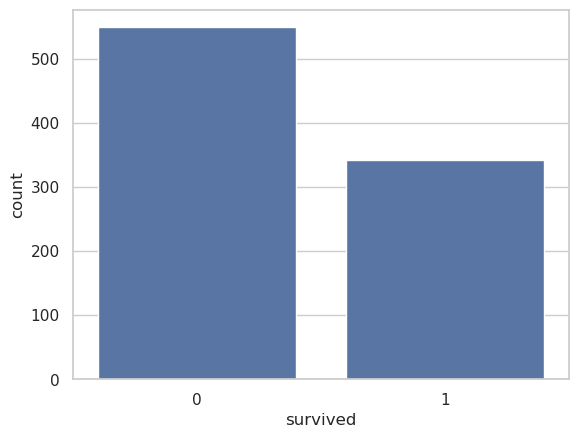

In [52]:

sns.countplot(data=titanic,x='survived')
plt.show()


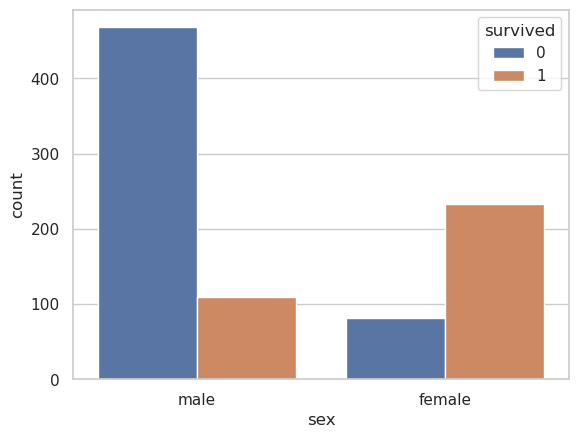

In [53]:

sns.countplot(data=titanic,x='sex',hue='survived')
plt.show()


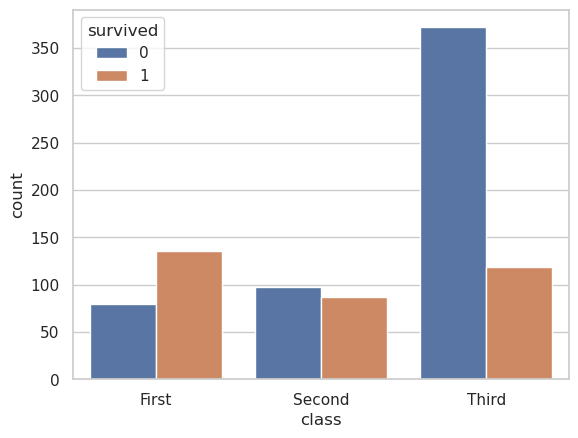

In [54]:

sns.countplot(data=titanic,x='class',hue='survived')
plt.show()



# 20 Kaggle EDA Rules

1. Missing values first
2. Target analysis first
3. Check imbalance
4. Never trust correlation blindly
5. Pairplot only on selected columns
6. Use hue aggressively
7. Boxplot before removing outliers
8. Outlier != bad data
9. Correlation != causation
10. Look for leakage
11. Check duplicates
12. Understand target distribution
13. Compare train/test distributions
14. Plot before feature engineering
15. Visualize skewness
16. Use log transforms wisely
17. Study feature interactions
18. Build baseline quickly
19. Simpler model first
20. Good EDA beats fancy models
